Monthly Sharpe (rf=0): 0.2414


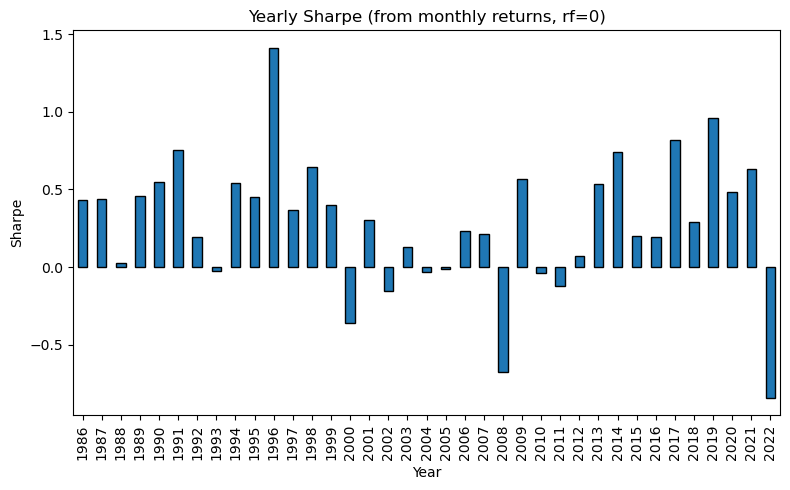

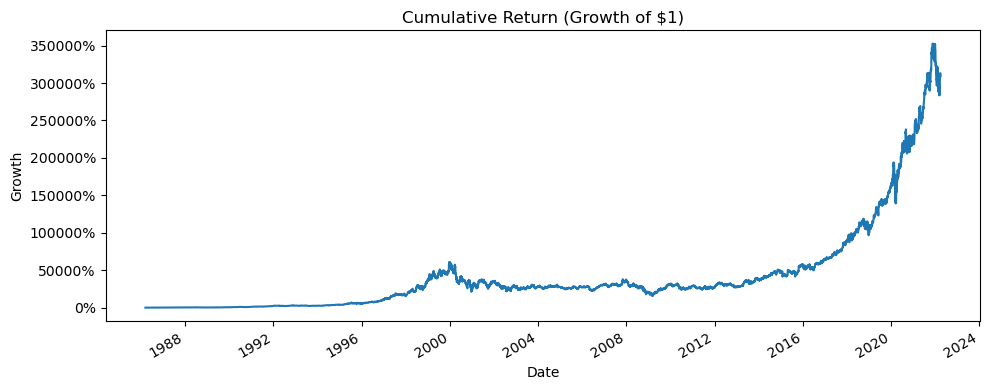

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

df = pd.read_csv("downloads/MSFT.csv")


if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = (df.dropna(subset=["Date"])
            .sort_values("Date")
            .set_index("Date"))
else:
    # Date already index
    df.index = pd.to_datetime(df.index, errors="coerce")
    df = df.dropna().sort_index()

# Daily returns
df["Return"] = df["Close"].pct_change()
df = df.dropna(subset=["Return"])

# Monthly returns (compounded)
monthly_ret = (1 + df["Return"]).resample("ME").prod() - 1

# Monthly Sharpe 
mu_m = monthly_ret.mean()
sigma_m = monthly_ret.std(ddof=0)
sharpe_m = mu_m / sigma_m if sigma_m != 0 else float("nan")
print(f"Monthly Sharpe (rf=0): {sharpe_m:.4f}")

# Yearly Sharpe from monthly returns
yr_sharpe = monthly_ret.groupby(monthly_ret.index.year).apply(
    lambda s: (s.mean() / s.std(ddof=0)) if s.std(ddof=0) != 0 else float("nan")
)

# Plot yearly Sharpe
fig, ax = plt.subplots(figsize=(8,5))
yr_sharpe.plot(kind="bar", edgecolor="black", ax=ax)
ax.set_title("Yearly Sharpe (from monthly returns, rf=0)")
ax.set_xlabel("Year"); ax.set_ylabel("Sharpe")
plt.tight_layout(); plt.show()

# Cumulative growth of $1
df["Cumulative"] = (1 + df["Return"]).cumprod() - 1
ax = df["Cumulative"].plot(figsize=(10,4))
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Cumulative Return (Growth of $1)")
ax.set_xlabel("Date"); ax.set_ylabel("Growth")
plt.tight_layout(); plt.show()
